# ELEC/PHYS 450/550 — Programming Assignment 3
# Implementing Shor's Factoring Algorithm

**Spring 2026 — Assoc. Prof. Dr. Mehmet Cengiz Onbaşlı**

---

### Instructions

- This assignment has **four parts**. Complete every `### YOUR CODE HERE ###` block.
- **Every code block must be accompanied by its paired Explanation cell.**  \
  Explanation cells are worth **50% of the total grade**.  \
  Cells left blank or containing only the placeholder text receive zero credit.
- Do **not** modify any cell labeled *DO NOT MODIFY*.
- Before submitting: **Kernel → Restart & Run All** — every cell must execute without error.
- **Deliverables:** submit (1) this completed `.ipynb` and (2) an exported PDF via KUHUB Learn.

### Honor Code

*I hereby certify that I have completed this assignment on my own without any help from anyone else.*

**Name:** `Ahmet Buğra Ertürk` &nbsp;&nbsp;&nbsp; **Student ID:** `86877`

---
## Setup — DO NOT MODIFY

Run this cell first to import all required libraries.

In [35]:
# ============================================================
# DO NOT MODIFY THIS CELL
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from math import gcd, pi
from fractions import Fraction
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFT, UnitaryGate
import warnings; warnings.filterwarnings("ignore")

print("Setup complete.")

Setup complete.


---
## Background

Shor's algorithm factors an integer $N$ by reducing the problem to **order finding**:
given $a$ coprime to $N$, find the smallest $r > 0$ such that $a^r \equiv 1 \pmod{N}$.
Once $r$ is known (even, with $a^{r/2} \not\equiv \pm 1 \pmod{N}$):

$$\gcd(a^{r/2}-1,\, N) \quad\text{and}\quad \gcd(a^{r/2}+1,\, N)$$

give the non-trivial factors. The quantum speedup comes from **Quantum Phase Estimation (QPE)**:
the unitary $U_a|y\rangle = |ay \bmod N\rangle$ has eigenvalues $e^{2\pi i s/r}$,
and QPE writes the phase $s/r$ into a counting register from which the continued
fractions algorithm extracts $r$.

Throughout Parts 1–3 you will work with $N = 15$, $a = 7$, $r = 4$,
using a $4$-qubit counting register and a $4$-qubit target register.
Part 4 generalizes to $N = 21$.

---
## Part 1 — Modular Exponentiation Unitary (25 pts)

The gate $U_a$ implements $|y\rangle \mapsto |a \cdot y \bmod N\rangle$ on an
$n_{\text{target}}$-qubit register. For states $|y\rangle$ with $y \geq N$
the gate acts as the identity. Because $\gcd(a, N) = 1$, the map is a bijection
on $\{0,\ldots,N-1\}$ and $U_a$ is a unitary permutation matrix.

### Task 1.1 — Implement `make_mod_exp_gate` (12 pts)

Implement the function below. It should:
1. Construct the $2^{n_{\text{target}}} \times 2^{n_{\text{target}}}$
   permutation matrix whose column $y$ is the standard basis vector $e_{ay \bmod N}$
   (for $y < N$) or $e_y$ (for $y \geq N$).
2. Return a `UnitaryGate` built from this matrix, labelled `f'U_{a}'`.

In [36]:
# ----------------------------------------------------------
# Task 1.1  make_mod_exp_gate
# ----------------------------------------------------------

def make_mod_exp_gate(a, N, n_target):
    """
    Build the unitary gate for |y> -> |a*y mod N> on n_target qubits.

    Parameters
    ----------
    a        : int   multiplier (must satisfy gcd(a, N) == 1)
    N        : int   modulus
    n_target : int   number of target qubits (register size = 2**n_target)

    Returns
    -------
    UnitaryGate
    """
    ### YOUR CODE HERE ###
    
    if gcd(a, N) != 1:
        raise ValueError("gcd(a, N) must be 1")

    if N >= 2**n_target:
        raise ValueError("N must be less than 2^n_target.")

    dim = 2**n_target
    U = np.zeros((dim, dim), dtype=complex)
    for y in range(dim):
        if y < N:
            U[a * y % N, y] = 1
        else:
            U[y, y] = 1
    return UnitaryGate(U, label=f"U_{a}")

### Explanation 1.1 — Conceptual Discussion (8 pts)

In the cell below, answer the following:
- **Why is $U_a$ a permutation matrix?** Connect the bijectivity of
  $y \mapsto ay \bmod N$ (for $\gcd(a,N)=1$) to the structure of the matrix.
- **Why use the identity for $y \geq N$?** What happens to these states
  physically? Why does padding with the identity preserve unitarity?
- **Why must $\gcd(a, N) = 1$?** Give an example of what goes wrong for
  $a$ not coprime to $N$ (e.g., $a = 5$, $N = 15$).

*(Replace the placeholder below with your explanation — 6–12 sentences.)*

### YOUR EXPLANATION HERE ###

We can say $y \mapsto ay \bmod N$ is bijective trivially, as well as mentioned in question. Therefore we can replace each columns of an Identity Matrix whose columns can be considered as one shot encoding of $y$ with $y \mapsto ay \bmod N$ and as a result of that we can see only permutation of the columns whose indices are less than $N$ and other columns would be same.

In quantum computing, we use qubits to represent $y$s with $m$ qubit such that $2^m \geq N$. Thus, we have paddings for $y \geq N$ which doesn't correspond to any $\bmod N$ so fill them with Identity. This help us to keep the state same if $y \geq N$ for corresponding state. Our final matrix has full rank, only one non-zero element in each row and columns which is 1 and is square, so $U^{\dagger} U = I$.

$y \mapsto ay \bmod N$ won't be injective if $\gcd(a, N) \neq 1$. 

For example, let $a=5$ and $N = 15$. 

$|0\rangle \mapsto |5 \cdot 0\ (\bmod 15)\rangle = |0\rangle$

$|3\rangle \mapsto |5 \cdot 3\ (\bmod 15)\rangle = |0\rangle$

$|6\rangle \mapsto |5 \cdot 6\ (\bmod 15)\rangle = |0\rangle$


### Task 1.2 — Verify the Orbit of $|1\rangle$ Under $U_7$ (5 pts)

Using the gate matrix, verify:
$$|1\rangle \xrightarrow{U_7} |7\rangle \xrightarrow{U_7}
  |4\rangle \xrightarrow{U_7} |13\rangle \xrightarrow{U_7} |1\rangle$$

Print the image of each state and confirm that $U_7^4 = I$ on the subspace
spanned by $\{|1\rangle, |7\rangle, |4\rangle, |13\rangle\}$
using `np.linalg.matrix_power`.

In [37]:
# ----------------------------------------------------------
# Task 1.2  Verify orbit and periodicity
# ----------------------------------------------------------

### YOUR CODE HERE ###
u_7 = make_mod_exp_gate(7, 15, 4)
u_7_matrix = u_7.to_matrix()

orbit = [1, 7, 4, 13]

for y in orbit:
    image = np.argmax(u_7_matrix[:, y]) 
    print(f"U_7 |{y}>  -->  |{image}>")

print("U_7^4 == I:", (np.linalg.matrix_power(u_7_matrix, 4) == np.eye(16)).all())


U_7 |1>  -->  |7>
U_7 |7>  -->  |4>
U_7 |4>  -->  |13>
U_7 |13>  -->  |1>
U_7^4 == I: True


In [38]:
# ============================================================
# AUTO-CHECK PART 1 — DO NOT MODIFY
# ============================================================
U7_gate = make_mod_exp_gate(7, 15, 4)
U7_mat  = U7_gate.to_matrix()

e = lambda k: np.eye(16)[k]

assert np.allclose(U7_mat @ e(1),  e(7)),  "U_7|1> must equal |7>"
assert np.allclose(U7_mat @ e(7),  e(4)),  "U_7|7> must equal |4>  (49 mod 15 = 4)"
assert np.allclose(U7_mat @ e(4),  e(13)), "U_7|4> must equal |13> (28 mod 15 = 13)"
assert np.allclose(U7_mat @ e(13), e(1)),  "U_7|13> must equal |1> (91 mod 15 = 1)"
assert np.allclose(U7_mat @ e(0),  e(0)),  "|0> must be a fixed point"

U7_4 = np.linalg.matrix_power(U7_mat, 4)
for idx in [1, 7, 4, 13]:
    assert np.allclose(U7_4 @ e(idx), e(idx), atol=1e-8), f"U_7^4|{idx}> != |{idx}>"

assert np.allclose(U7_mat @ U7_mat.conj().T, np.eye(16), atol=1e-8), "U_7 must be unitary"

print("All Part 1 auto-checks passed ✓")

All Part 1 auto-checks passed ✓


---
## Part 2 — Phase Estimation Circuit (25 pts)

Build the full QPE circuit for Shor's algorithm. The circuit has
$n_{\text{count}}$ counting qubits (indices $0, \ldots, n_{\text{count}}-1$)
and $n_{\text{target}}$ target qubits (indices
$n_{\text{count}}, \ldots, n_{\text{count}}+n_{\text{target}}-1$).
Only the counting qubits are measured.

**Circuit structure (five steps):**
1. Flip target qubit $n_{\text{count}}$ to prepare $|1\rangle$ in the target register.
2. Apply Hadamard to all counting qubits.
3. For each counting qubit $k = 0, \ldots, n_{\text{count}}-1$:
   append the **controlled-$U_a^{2^k}$** gate with qubit $k$ as control and
   the $n_{\text{target}}$ target qubits as targets.
4. Append `QFT(n_count, inverse=True)` on qubits $0, \ldots, n_{\text{count}}-1$.
5. Measure qubits $0, \ldots, n_{\text{count}}-1$ into classical bits
   $0, \ldots, n_{\text{count}}-1$.

> **Implementation note:** Use `UnitaryGate(mat, label=...)` to wrap
> $U_a^{2^k}$ and `.control(1)` to make it controlled. When appending with
> `qc.append(ctrl_gate, qubit_list)`, the **first** qubit in `qubit_list`
> is the control; the remaining qubits are the target register.

### Task 2.1 — Implement `quantum_phase_estimation` (12 pts)

In [39]:
# ----------------------------------------------------------
# Task 2.1  quantum_phase_estimation
# ----------------------------------------------------------

def quantum_phase_estimation(a, N, n_count, n_target):
    """
    Build the QPE circuit for Shor's algorithm.

    Parameters
    ----------
    a        : int   base (coprime to N)
    N        : int   number to factor
    n_count  : int   number of counting qubits
    n_target : int   number of target qubits

    Returns
    -------
    QuantumCircuit  with (n_count + n_target) qubits and n_count classical bits
    """
    ### YOUR CODE HERE ###
    qc = QuantumCircuit(n_count + n_target, n_count)
    qc.x(n_count)
    qc.h(range(n_count))

    for k in range(n_count):
        pow = 2**k
        u_gate = make_mod_exp_gate(a, N, n_target)
        ctrl_gate = UnitaryGate(np.linalg.matrix_power(u_gate.to_matrix(), pow), label=f"U_{a}^{pow}").control(1)
        qc.append(ctrl_gate, [k] + list(range(n_count, n_count + n_target)))

    qft_inv = QFT(n_count, inverse=True).to_gate(label="QFT^-1")
    qc.append(qft_inv, range(n_count))

    qc.measure(range(n_count), range(n_count))

    return qc


### Task 2.2 — Draw and Simulate (5 pts)

Draw the circuit (decomposed one level) and run it for 4096 shots on
`AerSimulator`. Convert bitstring results to integers and plot a histogram.
Identify the dominant peaks.

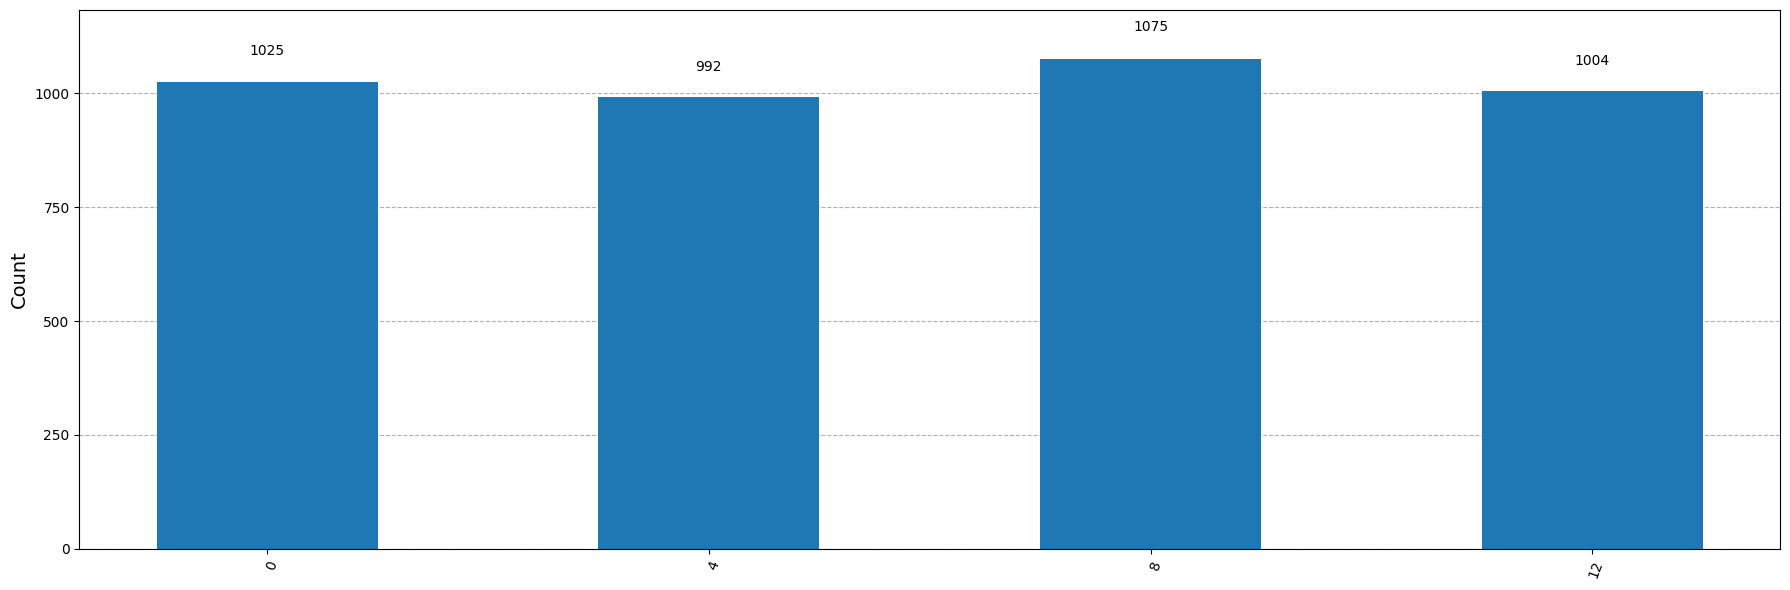

Top Dominant Peaks:
Value:   8 | Probability: 0.262
Value:   0 | Probability: 0.250
Value:  12 | Probability: 0.245
Value:   4 | Probability: 0.242


In [40]:
# ----------------------------------------------------------
# Task 2.2  Draw and simulate
# ----------------------------------------------------------

### YOUR CODE HERE ###
n_count = 4
n_target = 4
a, N = 7, 15

qc = quantum_phase_estimation(a, N, n_count, n_target)
display(qc.decompose().draw("mpl"))

sim = AerSimulator()
tqc = transpile(qc, sim)
result = sim.run(tqc, shots=4096).result()
counts = result.get_counts()

int_counts = {int(k, 2): v for k, v in counts.items()}

display(plot_histogram(int_counts, figsize=(18, 6)))

sorted_counts = sorted(int_counts.items(), key=lambda x: x[1], reverse=True)
print("Top Dominant Peaks:")
for val, count in sorted_counts[:11]:
    print(f"Value: {val:3d} | Probability: {count/4096:.3f}")

### Explanation 2 — Circuit Design Discussion (8 pts)

Answer the following:
- **Qubit ordering for controlled gates:** Why must the control qubit come
  first in the `qubit_list` passed to `qc.append`? What would happen if the
  order were reversed?
- **Why peaks at $\{0, 4, 8, 12\}$?** Use the eigenvalue structure of $U_7$
  and the phase $s/r$ to derive mathematically why these four values appear
  with equal probability for $n_{\text{count}} = 4$.
- **Alternative initialization:** What would be measured if the target
  register were placed in $\tfrac{1}{2}(|1\rangle + |7\rangle + |4\rangle + |13\rangle)$
  instead of $|1\rangle$? Would the output change? Justify.

*(Replace the placeholder below — 6–12 sentences.)*

### YOUR EXPLANATION HERE ###

* It's because of the qiskit. In qiskit when we create a controlled gate with `.control(1)` the first qubit will be control qubit in the `qubit_list` passed to `qc.append`. If the order were reversed, unitary gate would be controlled by one of the target qubit instead of counting qubits and the algorithm wouldn't work.

* The peaks are determined by the eigenvalues of $U_7$. For $N=15$, $a=7$, the period is $r=4$. So, the eigenvalues of $U_7$ are $\lambda_s=e^{2\pi i(s/r)}$ for $s \in \{0, 1, 2, 3\}$. $s/r = 0, 0.25, 0.50, 0.75$ respectively for $s \in \{0, 1, 2, 3\}$ and we have 4 qubit so $2^4=16$ possible outcome. According to QFT kickback mechanism $s/r=y/2^n$ where $y$ is integer outcome and $n$ is number of qubits. So, our outcomes, $y$, will be $0\cdot16 = 0,\ 0.25\cdot16 = 4,\ 0.50\cdot16 = 8,\ 0.75\cdot16 = 12$. Also, since the initial state $∣1\rangle$ is an equal superposition of the four eigenvectors and the QPE algorithm collapses into each eigenvector with probability $1/r=1/4$. Thus, each has same probability.

* The initial state $\tfrac{1}{2}(|1\rangle + |7\rangle + |4\rangle + |13\rangle)$ is the eigenstate corresponding to $\lambda_0=e^{2\pi i(0/4)}=1$. In this case, the initial state doesn't have any overlap with other eigenvalues, so the result will be $0$ with $100\%$ probability.

In [41]:
# ============================================================
# AUTO-CHECK PART 2 — DO NOT MODIFY
# ============================================================
qc_chk = quantum_phase_estimation(7, 15, 4, 4)
assert qc_chk.num_qubits == 8,  "Circuit must have 8 qubits (4 counting + 4 target)"
assert qc_chk.num_clbits == 4,  "Circuit must have 4 classical bits"

sim    = AerSimulator()
counts = sim.run(transpile(qc_chk, sim), shots=4096).result().get_counts()

# Convert to integer outcomes
int_counts = {}
for bs, c in counts.items():
    v = int(bs, 2)
    int_counts[v] = int_counts.get(v, 0) + c

expected_peaks = {0, 4, 8, 12}
peak_shots = sum(int_counts.get(y, 0) for y in expected_peaks)
total_shots = sum(int_counts.values())
peak_frac   = peak_shots / total_shots

assert peak_frac > 0.85, (
    f"Expected > 85% of shots on peaks {{0,4,8,12}}, got {peak_frac:.1%}. "
    "Check target initialization and controlled-gate ordering."
)

print(f"Peak concentration: {peak_frac:.1%}  (expected > 85%)  ✓")
print("All Part 2 auto-checks passed ✓")

Peak concentration: 100.0%  (expected > 85%)  ✓
All Part 2 auto-checks passed ✓


---
## Part 3 — Period Extraction and Factor Pipeline (25 pts)

With the QPE circuit producing measurement outcomes $y$, the classical
post-processing chain is:

$$y \;\xrightarrow{\text{CF}}\; r_{\text{cand}} \;\xrightarrow{\text{validate}}\;
r \;\xrightarrow{\text{GCD}}\; (p, q).$$

Each step can fail: CF may return a divisor of $r$ rather than $r$ itself;
the period check $a^r \equiv 1 \pmod N$ may fail; the GCDs may be trivial.
Your pipeline must handle all these cases gracefully.

### Task 3.1 — `extract_period` (5 pts)

Implement `extract_period(y, n_count, N)` that returns the denominator of the
best rational approximation $y/2^{n_{\text{count}}} \approx s/r$ with
denominator $\leq N$, or `None` for $y = 0$.

In [42]:
# ----------------------------------------------------------
# Task 3.1  extract_period via continued fractions
# ----------------------------------------------------------

def extract_period(y, n_count, N):
    """
    Candidate period from measurement outcome y.

    Returns the denominator of Fraction(y, 2**n_count).limit_denominator(N),
    or None if y == 0.
    """
    ### YOUR CODE HERE ###
    if y == 0:
        return None
    return Fraction(y, 2**n_count).limit_denominator(N).denominator

### Task 3.2 — `validate_and_factor` (5 pts)

Implement `validate_and_factor(a, r_cand, N)` that:
1. Returns `None` if `r_cand` is `None` or odd.
2. Returns `None` if $a^{r_{\text{cand}}} \not\equiv 1 \pmod N$ (failed order check).
3. Computes $x = a^{r_{\text{cand}}/2} \bmod N$.
4. Returns `None` if $x \equiv N - 1$ (i.e., $a^{r/2} \equiv -1$) or $x \equiv 1$.
5. Otherwise returns the first non-trivial factor found from
   $\gcd(x-1, N)$ and $\gcd(x+1, N)$, as a tuple $(p, q)$ with $p \leq q$.

In [43]:
# ----------------------------------------------------------
# Task 3.2  validate_and_factor
# ----------------------------------------------------------

def validate_and_factor(a, r_cand, N):
    """
    Attempt to return (p, q) with p*q == N and 1 < p <= q < N,
    or None if the candidate fails any validity check.
    """
    ### YOUR CODE HERE ###
    if r_cand is None:
        return None
    if r_cand % 2 != 0:
        return None
    if pow(a, r_cand, N) != 1:
        return None
    p = gcd(pow(a, r_cand//2) - 1, N)
    q = gcd(pow(a, r_cand//2) + 1, N)
    if p == 1 or p == N or q == 1 or q == N:
        return None
    return (min(p, q), max(p, q))

### Task 3.3 — `run_shor` and Pipeline Analysis (10 pts)

Implement `run_shor(a, N, n_count, n_target, shots=4096)` that:
1. Builds and runs the QPE circuit.
2. Iterates over every unique measurement outcome (in any order).
3. Attempts `extract_period` then `validate_and_factor` for each.
4. Returns `(factors, success_rate, counts)` where:
   - `factors` is the first successful tuple found (or `None`),
   - `success_rate` is the fraction of total shots corresponding to outcomes
     that successfully yielded a non-trivial factoring,
   - `counts` is the raw measurement dictionary.

Run `run_shor(7, 15, 4, 4)` and display the histogram and results.

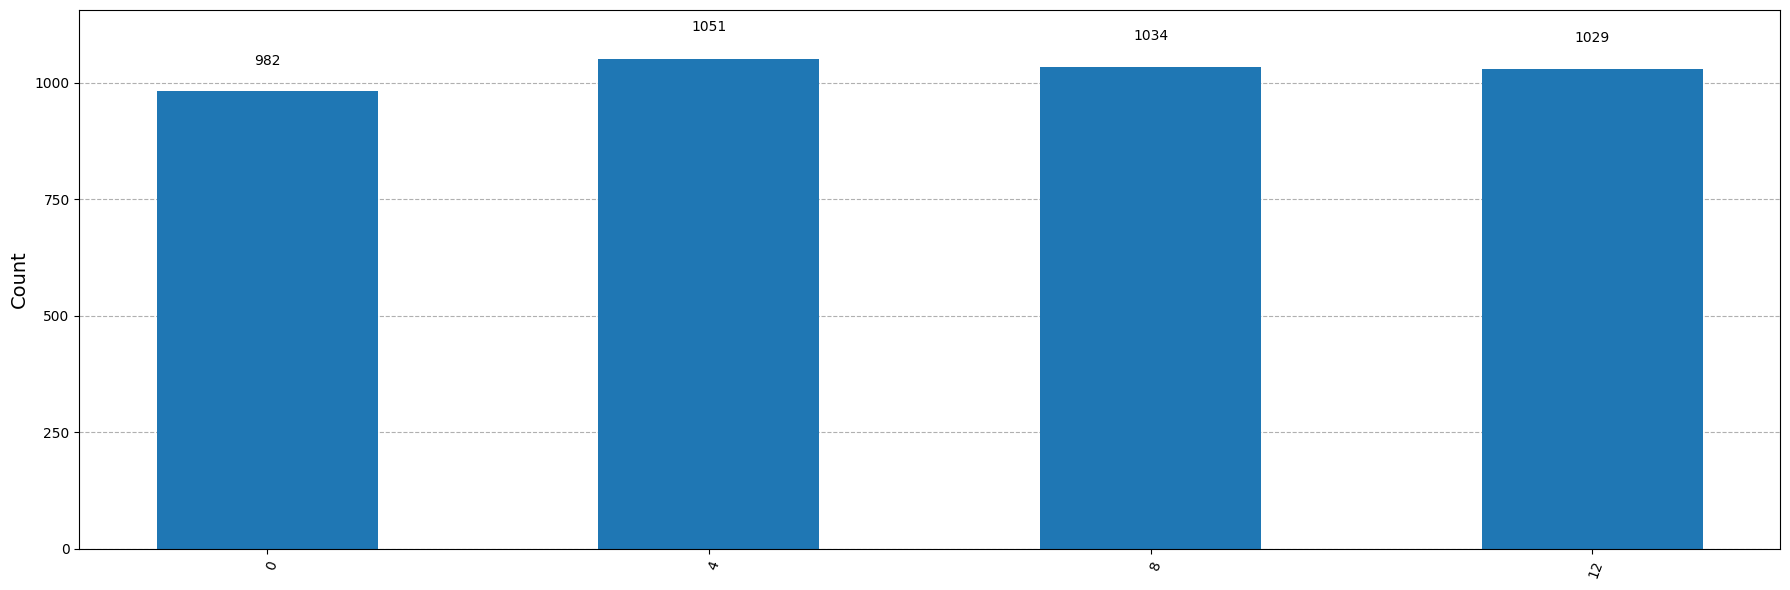

Factors of 15 found: (3, 5) with success rate 50.8%


In [44]:
# ----------------------------------------------------------
# Task 3.3  run_shor
# ----------------------------------------------------------

def run_shor(a, N, n_count, n_target, shots=4096):
    """
    Complete Shor's algorithm pipeline.

    Returns
    -------
    factors      : tuple (p, q) or None
    success_rate : float in [0, 1]
    counts       : dict  raw measurement counts
    """
    ### YOUR CODE HERE ###
    qc = quantum_phase_estimation(a, N, n_count, n_target)
    sim = AerSimulator()
    tqc = transpile(qc, sim)
    result = sim.run(tqc, shots=shots).result()
    counts = result.get_counts()
    int_counts = {int(k, 2): v for k, v in counts.items()}
    success_count = 0
    factors = None
    for y, c in int_counts.items():
        r_cand = extract_period(y, n_count, N)
        f = validate_and_factor(a, r_cand, N)
        if f is not None:
            success_count += c
            if factors is None:
                factors = f
    success_rate = success_count / shots
    
    return factors, success_rate, counts


# ── Run and display ──────────────────────────────────────────────────────────
### YOUR CODE HERE ###
a, N = 7, 15
n_count, n_target = 4, 4
factors, success_rate, counts = run_shor(a, N, n_count, n_target)
int_counts = {int(k, 2): v for k, v in counts.items()}
display(plot_histogram(int_counts, figsize=(18, 6)))
print(f"Factors of {N} found: {factors} with success rate {success_rate:.1%}")

### Explanation 3 — Pipeline Analysis (5 pts)

Answer the following:
- **Per-outcome analysis for $a=7$, $N=15$, $n_{\text{count}}=4$:**
  For each $y \in \{0, 4, 8, 12\}$, trace through the full pipeline.
  Which outcomes lead to a valid factoring? Which fail, and why?
- **The $\pm 1$ condition:** Explain with a concrete example why
  $a^{r/2} \equiv +1 \pmod N$ also gives trivial GCDs (not just $-1$).
- **Failure recovery:** If `run_shor` returns `None`, what would you do next
  in a real implementation?

*(Replace the placeholder below — 6–12 sentences.)*

### YOUR EXPLANATION HERE ###

* With $n_{count}=4$, our denominator is $2^4=16$. The true period of $7(mod15)$ is $r=4$.

| Outcome ($y$) | Phase $\theta=y/16$ | $r_{cand}$ | $7^r \equiv 1$ | $7^r \not\equiv -1$ | Result |
|---------------|---------------------|------------|----------------|---------------------|--------|
| 0 | 0 | - | - | - | Fail, since it provides no info. | 
| 4 | 0.25 | 4 | Pass ($7^4=2401 (mod\ 15) \equiv 1$) | Pass ($7^2=49 (mod\ 15) \equiv 4$) | $\gcd(50, N)=5$ and $\gcd(48, N)=3$ |
| 8 | 0.50 | 2 | Fail ($7^2=49 (mod\ 15) \equiv 4$) | - | Fail, since $r_{cand}$ is a divisor of $r$ |
| 12 | 0.75 | 4 | Pass ($7^4=2401 (mod\ 15) \equiv 1$) | Pass ($7^2=49 (mod\ 15) \equiv 4$) | $\gcd(50, N)=5$ and $\gcd(48, N)=3$ |


* The factors are $\gcd((a^{r/2}-1),\ N)$ and $\gcd((a^{r/2}+1),\ N)$. If $a^{r/2} \equiv +1 \pmod N$, $a^{r/2}-1 \equiv 0 \pmod N$ means $a^{r/2}-1 = 15k$ and $a^{r/2}+1 = 15k+2$ where $k\geq0\in\mathbb{Z}$ so $\gcd((a^{r/2}+1),\ N)=1$ and $\gcd((a^{r/2}-1),\ N)=N$.

* Re-run with new $a$ or let it find a new period.

In [45]:
# ============================================================
# AUTO-CHECK PART 3 — DO NOT MODIFY
# ============================================================

# --- extract_period ---
assert extract_period(0, 4, 15)  is None,  "y=0 must return None"
assert extract_period(4, 4, 15)  == 4,     "4/16=1/4  ->  r_cand=4"
assert extract_period(12, 4, 15) == 4,     "12/16=3/4 ->  r_cand=4"
assert extract_period(8, 4, 15)  == 2,     "8/16=1/2  ->  r_cand=2 (divisor of r)"

# --- validate_and_factor ---
assert validate_and_factor(7, None, 15) is None, "None r_cand must return None"
assert validate_and_factor(7, 3,    15) is None, "odd r must return None"
assert validate_and_factor(7, 2,    15) is None, "r=2 fails: 7^2=4 != 1 mod 15"

result = validate_and_factor(7, 4, 15)
assert result is not None, "a=7, r=4, N=15 must succeed"
p, q = sorted(result)
assert p * q == 15 and p > 1 and q > 1, f"Expected non-trivial factors of 15, got {result}"

# --- run_shor ---
factors, sr, _ = run_shor(7, 15, 4, 4, shots=4096)
assert factors is not None, "run_shor must find factors (got None)"
p2, q2 = sorted(factors)
assert p2 * q2 == 15 and p2 > 1, "run_shor must return non-trivial factors of 15"
assert sr > 0.30, f"Success rate must exceed 30%, got {sr:.1%}"

print(f"Factors found: {factors},  success rate: {sr:.1%}  ✓")
print("All Part 3 auto-checks passed ✓")

Factors found: (3, 5),  success rate: 50.4%  ✓
All Part 3 auto-checks passed ✓


---
## Part 4 — Generalization to $N = 21$ (25 pts)

You must now factor $N = 21 = 3 \times 7$ using the same pipeline, but with
parameters you choose yourself.

**Parameter selection guidelines:**
- $n_{\text{target}}$: must satisfy $2^{n_{\text{target}}} \geq N$.
- $n_{\text{count}}$: the phase precision is $1/2^{n_{\text{count}}}$;
  to distinguish $r$ values up to $N$, a useful rule of thumb is
  $n_{\text{count}} \geq 2\lceil \log_2 N \rceil$.
  You are encouraged to experiment — start with $n_{\text{count}} \in [5, 8]$.
- Base $a$: choose any $a$ coprime to 21, i.e., $\gcd(a, 21) = 1$.

### Task 4.1 — Factor $N = 21$ (10 pts)

Implement `factor_21(a, n_count, n_target, shots=4096)` using your pipeline.
Demonstrate a **successful** factoring run: print the factors and display
the measurement histogram. Document your parameter choices.

Running Shor's algorithm for N=21 with a=2, n_count=10, n_target=5, shots=4096


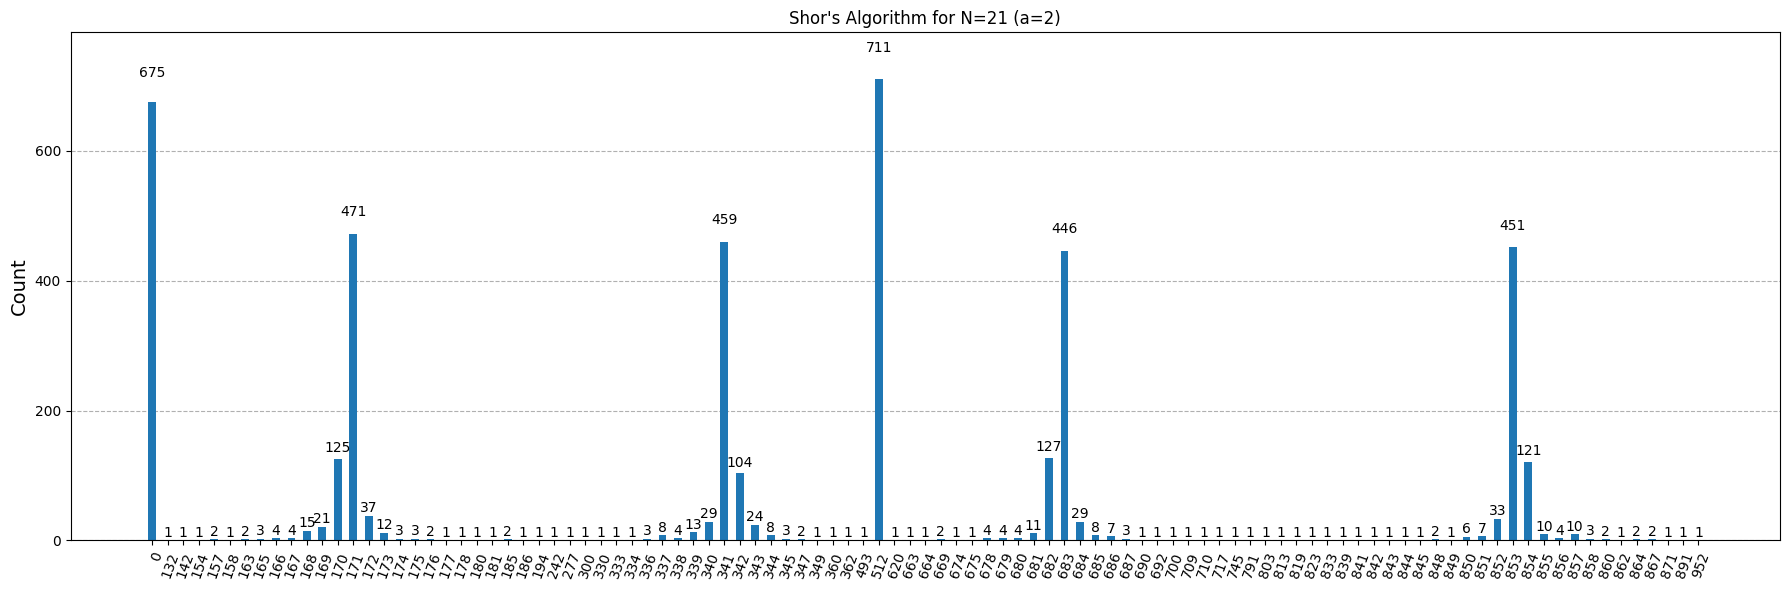

Factors of 21 found: (3, 7) with success rate 32.6%


In [46]:
# ----------------------------------------------------------
# Task 4.1  factor_21
# ----------------------------------------------------------

### YOUR CODE HERE: choose n_count and n_target ###
N21        = 21
n_count21  = 10   # <-- choose this
n_target21 = 5   # <-- choose this
a21        = 2   # <-- choose a base coprime to 21


def factor_21(a, n_count, n_target, shots=4096):
    """Factor N=21 using the Shor pipeline. Returns (p, q) or None."""
    ### YOUR CODE HERE ###
    print(f"Running Shor's algorithm for N=21 with a={a}, n_count={n_count}, n_target={n_target}, shots={shots}")
    factors, success_rate, counts = run_shor(a, N21, n_count, n_target, shots)
    int_counts = {int(k, 2): v for k, v in counts.items()}
    display(plot_histogram(int_counts, figsize=(18, 6), title=f"Shor's Algorithm for N=21 (a={a})"))
    print(f"Factors of 21 found: {factors} with success rate {success_rate:.1%}")
    return factors


### YOUR CODE HERE: run and display results ###
factors = factor_21(a21, n_count21, n_target21)

### Task 4.2 — Base Sweep (10 pts)

Sweep over all bases $a \in \{2, 4, 5, 8, 10, 11, 13, 16, 17, 19, 20\}$
(all values coprime to 21, excluding trivial cases). For each, run 2048 shots
and record the empirical success rate. Display a bar chart of success rates.
Annotate the chart with the classical period $r$ for each base
(you may compute $r$ classically using a helper function).

2          | 6            |       32.8%
4          | 3            |        0.0%
5          | 6            |        0.0%
8          | 2            |       50.6%
10         | 6            |       32.8%
11         | 6            |       33.1%
13         | 2            |       48.8%
16         | 3            |        0.0%
17         | 6            |        0.0%
19         | 6            |       32.8%
20         | 2            |        0.0%


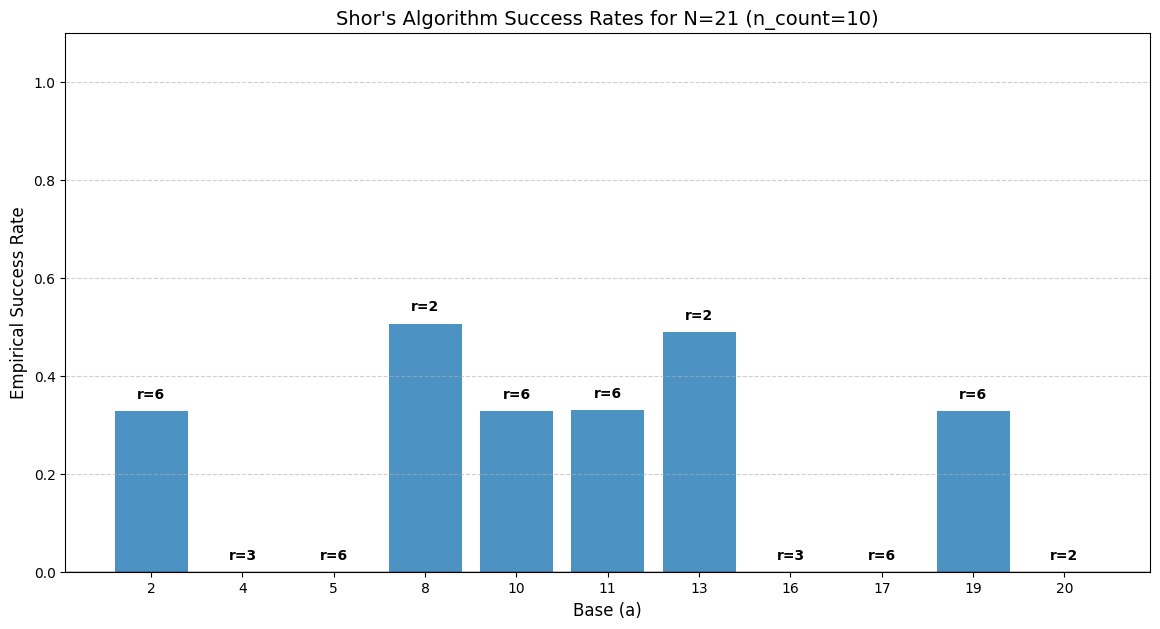

In [47]:
# ----------------------------------------------------------
# Task 4.2  Base sweep for N=21
# ----------------------------------------------------------

### YOUR CODE HERE ###
def get_classical_period(a, N):
    r = 1
    while pow(a, r, N) != 1:
        r += 1
    return r

bases = [2, 4, 5, 8, 10, 11, 13, 16, 17, 19, 20]
success_rates = []
periods = []

for a in bases:
    r = get_classical_period(a, N21)
    periods.append(r)

    _, rate, _ = run_shor(a, N21, n_count21, n_target21, shots=2048)
    success_rates.append(rate)
    
    print(f"{a:<10} | {r:<12} | {rate:>11.1%}")

plt.figure(figsize=(14, 7))
bars = plt.bar([str(a) for a in bases], success_rates, alpha=0.8)

for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, 
             f'r={periods[i]}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, 1.1)
plt.axhline(y=0.0, color='black', linestyle='-', linewidth=1)
plt.xlabel('Base (a)', fontsize=12)
plt.ylabel('Empirical Success Rate', fontsize=12)
plt.title(f'Shor\'s Algorithm Success Rates for N=21 (n_count={n_count21})', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

### Explanation 4 — Parameter Choices and Implications (5 pts)

Answer the following:
- **Why did you choose your $n_{\text{count}}$?**
  What precision is theoretically needed to identify a period $r \leq 21$
  via continued fractions, and how does your choice meet (or approximate) that
  requirement? What is the trade-off with simulation time?
- **Which bases fail for $N = 21$?** For each failing base, state the
  classical period $r$ and explain why the pipeline fails
  (odd $r$, $a^{r/2} \equiv \pm 1$, or other).
- **RSA-2048 implications:** In 3–5 sentences, explain why Shor's
  polynomial-time complexity breaks RSA in principle, yet current quantum
  hardware cannot factor RSA-2048. Reference the qubit resource estimates
  from the course material.

*(Replace the placeholder below — 8–15 sentences.)*

### YOUR EXPLANATION HERE ###

* According to week 9 notes, for the CF algorithm, $|y/2^{n_{count}}-s/r|\leq1/2r^2$ should be satisfied for sufficient precision. Since $r<N<2^n$ where n is the bit number to represent N, we can choose $n_{count} \geq 2n$. Thus, $n_{count} = 2n + \left\lceil \log \left( 2 + \frac{1}{2\epsilon} \right) \right\rceil$ where $1−\epsilon$ is at least probability of success. Therefore, I choose 10 for number of counting qubits. The trade-off with simulation time is that, the time increase exponentially.

* It fails for $a \in \{4,\ 5,\ 16,\ 17,\ 20\}$

| Base ($a$) | Period ($r$) | $r$ is Even? | $a^{r/2} \not\equiv -1 \pmod{21}$ | Reason |
| --- | --- | --- | --- | --- |
| 4 | 3 | Fail | - | r is odd |
| 5 | 6 | Pass | Fail ($5^3 \equiv -1$) | trivial |
| 16 | 3 | Fail | - | r is odd |
| 17 | 6 | Pass | Fail ($17^3 \equiv -1$) | trivial |
| 20 | 2 | Pass | Fail ($20^1 \equiv -1$) | trivial |

* According to week 9 notes section 9, the complexity of the Shor's algorithm is $O(n^3)$ and it can be running via quantum computers in hours or days. However it requires roughly at least 4096 qubits which is impossible to get meaningful outputs in NISQ era due to the noise and it requires millions of qubits for error correction.

Running Shor's algorithm for N=21 with a=2, n_count=10, n_target=5, shots=4096


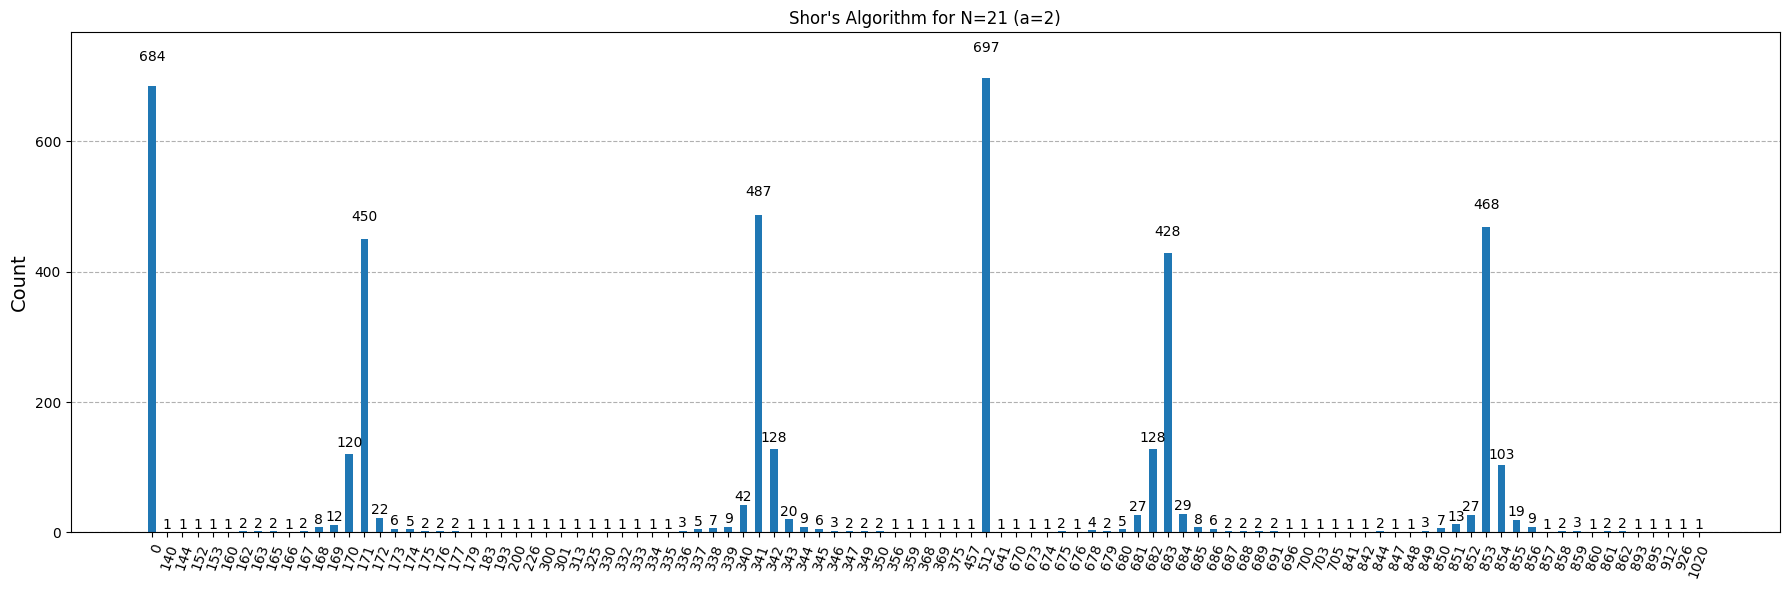

Factors of 21 found: (3, 7) with success rate 31.2%
N=21 factored successfully: 3 × 7 = 21  ✓
Parameters used: a=2, n_count=10, n_target=5
All Part 4 auto-checks passed ✓


In [48]:
# ============================================================
# AUTO-CHECK PART 4 — DO NOT MODIFY
# ============================================================

# --- Parameter sanity ---
assert n_count21  is not None, "Set n_count21"
assert n_target21 is not None, "Set n_target21"
assert a21        is not None, "Set a21"
assert 2**n_target21 >= N21,   f"n_target21={n_target21} is too small for N=21"
assert gcd(a21, N21) == 1,     f"a21={a21} must be coprime to 21"
assert n_count21 >= 4,         "n_count21 must be at least 4 for useful phase resolution"

# --- Factoring check ---
result21 = factor_21(a21, n_count21, n_target21, shots=4096)
assert result21 is not None, (
    "factor_21 returned None. Try a different base or increase n_count21."
)
p21, q21 = sorted(result21)
assert p21 * q21 == 21 and p21 > 1 and q21 > 1, (
    f"Expected non-trivial factors of 21, got {result21}"
)

print(f"N=21 factored successfully: {p21} × {q21} = {p21*q21}  ✓")
print(f"Parameters used: a={a21}, n_count={n_count21}, n_target={n_target21}")
print("All Part 4 auto-checks passed ✓")